In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)

X = mnist.data
y = mnist.target.astype(int)

print(X.shape)
print(y.shape)

(70000, 784)
(70000,)


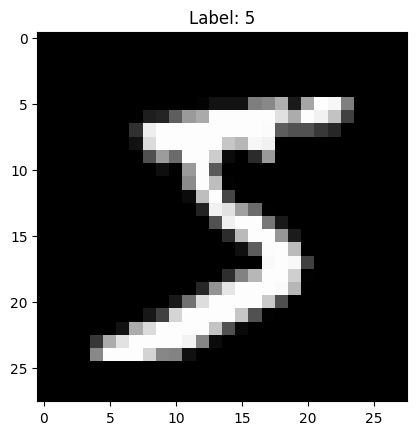

In [3]:
plt.imshow(X[0].reshape(28,28), cmap='gray')
plt.title(f"Label: {y[0]}")
plt.show()

In [4]:
X = X / 255.0

In [5]:
import pandas as pd

pd.get_dummies(y)

,0,1,2,3,4,5,6,7,8,9
0,False,False,False,False,False,True,False,False,False,False
1,True,False,False,False,False,False,False,False,False,False
2,False,False,False,False,True,False,False,False,False,False
3,False,True,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...
69995,False,False,True,False,False,False,False,False,False,False
69996,False,False,False,True,False,False,False,False,False,False
69997,False,False,False,False,True,False,False,False,False,False
69998,False,False,False,False,False,True,False,False,False,False


In [6]:
Y = pd.get_dummies(y).astype(int)

In [7]:
print(Y.head())

   0  1  2  3  4  5  6  7  8  9
0  0  0  0  0  0  1  0  0  0  0
1  1  0  0  0  0  0  0  0  0  0
2  0  0  0  0  1  0  0  0  0  0
3  0  1  0  0  0  0  0  0  0  0
4  0  0  0  0  0  0  0  0  0  1


In [8]:
Y = pd.get_dummies(y).astype(float).to_numpy()

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

In [10]:
print(X_train.shape)
print(X_test.shape)

print(Y_train.shape)
print(Y_test.shape)

(56000, 784)
(14000, 784)
(56000, 10)
(14000, 10)


In [37]:
input_size = 784
hidden1_size = 64
hidden2_size = 32
output_size = 10


In [38]:
W1 = np.random.randn(input_size, hidden1_size) * np.sqrt(2 / input_size)
b1 = np.zeros((1, hidden1_size))

W2 = np.random.randn(hidden1_size, hidden2_size) * np.sqrt(2 / hidden1_size)
b2 = np.zeros((1, hidden2_size))

W3 = np.random.randn(hidden2_size, output_size) * np.sqrt(2 / hidden2_size)
b3 = np.zeros((1, output_size))

In [39]:
def relu(z):
    return np.maximum(0, z)


In [40]:
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)


In [41]:
def forward(X):

    Z1 = X @ W1 + b1
    A1 = relu(Z1)

    Z2 = A1 @ W2 + b2
    A2 = relu(Z2)

    Z3 = A2 @ W3 + b3
    A3 = softmax(Z3)

    return Z1, A1, Z2, A2, Z3, A3

In [44]:
Z1, A1, Z2, A2, Z3, A3 = forward(X_train)

print(Z1.shape)
print(A1.shape)

print(Z2.shape)
print(A2.shape)

print(Z3.shape)
print(A3.shape)

(56000, 64)
(56000, 64)
(56000, 32)
(56000, 32)
(56000, 10)
(56000, 10)


In [45]:
def compute_loss(Y_true, Y_pred):

    
    epsilon = 1e-15

    Y_pred = np.clip(Y_pred, epsilon, 1 - epsilon)

    loss = -np.mean(np.sum(Y_true * np.log(Y_pred), axis=1))

    return loss

In [46]:
def relu_derivative(z):
    return (z > 0).astype(float)

In [47]:
def backward(X, Y, Z1, A1, Z2, A2, Z3, A3):

    m = X.shape[0]

    dZ3 = A3 - Y

    dW3 = (A2.T @ dZ3) / m
    db3 = np.sum(dZ3, axis=0, keepdims=True) / m

    dA2 = dZ3 @ W3.T
    dZ2 = dA2 * relu_derivative(Z2)

    dW2 = (A1.T @ dZ2) / m
    db2 = np.sum(dZ2, axis=0, keepdims=True) / m

    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * relu_derivative(Z1)

    dW1 = (X.T @ dZ1) / m
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m

    return dW1, db1, dW2, db2, dW3, db3

In [48]:
def update_parameters(
    dW1, db1,
    dW2, db2,
    dW3, db3,
    learning_rate
):

    global W1, b1, W2, b2, W3, b3

    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    W3 -= learning_rate * dW3
    b3 -= learning_rate * db3

In [49]:
learning_rate = 0.3
epochs = 300

for epoch in range(epochs):

    Z1, A1, Z2, A2, Z3, A3 = forward(X_train)

    loss = compute_loss(Y_train, A3)

    dW1, db1, dW2, db2, dW3, db3 = backward(
        X_train,
        Y_train,
        Z1, A1,
        Z2, A2,
        Z3, A3
    )

    update_parameters(
        dW1, db1,
        dW2, db2,
        dW3, db3,
        learning_rate
    )

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")

Epoch 0, Loss: 2.3945
Epoch 10, Loss: 1.2117
Epoch 20, Loss: 0.8930
Epoch 30, Loss: 0.8163
Epoch 40, Loss: 0.5058
Epoch 50, Loss: 0.4074
Epoch 60, Loss: 0.3732
Epoch 70, Loss: 0.3652
Epoch 80, Loss: 0.3203
Epoch 90, Loss: 0.3426
Epoch 100, Loss: 0.2853
Epoch 110, Loss: 0.2712
Epoch 120, Loss: 0.2647
Epoch 130, Loss: 0.2963
Epoch 140, Loss: 0.2463
Epoch 150, Loss: 0.2353
Epoch 160, Loss: 0.2278
Epoch 170, Loss: 0.2211
Epoch 180, Loss: 0.2148
Epoch 190, Loss: 0.2090
Epoch 200, Loss: 0.2036
Epoch 210, Loss: 0.1985
Epoch 220, Loss: 0.1937
Epoch 230, Loss: 0.1899
Epoch 240, Loss: 0.1921
Epoch 250, Loss: 0.4243
Epoch 260, Loss: 0.1836
Epoch 270, Loss: 0.1766
Epoch 280, Loss: 0.1719
Epoch 290, Loss: 0.1680


In [50]:
def predict(X):

    _, _, _, _, _, A3 = forward(X)

    return np.argmax(A3, axis=1)

In [51]:
train_predictions = predict(X_train)

train_actual = np.argmax(Y_train, axis=1)

train_accuracy = np.mean(train_predictions == train_actual)

print(f"Training Accuracy: {train_accuracy:.4f}")

Training Accuracy: 0.9520


In [52]:
test_predictions = predict(X_test)

test_actual = np.argmax(Y_test, axis=1)

test_accuracy = np.mean(test_predictions == test_actual)

print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 0.9495
